## Capstone Project – Airbnb EDA  
## Madrid vs Tokyo

### Objective
Compare Airbnb markets in Madrid and Tokyo to understand pricing drivers and prepare for machine learning and chatbot development.

### Team
- Abril Balbi  
- Shirin Aliyeva
- Georgi Opnakov  
- Juan David Rodriguez  

## Project Context

We analyze Airbnb listings to:

- Understand pricing patterns  
- Compare two global tourism markets  
- Identify key drivers of price  

### Why Madrid vs Tokyo?

- Madrid → European tourism hub  
- Tokyo → fast-growing global destination  

This allows a cross-market comparison.

## Data Source

The datasets used in this analysis come from **Inside Airbnb**, an open data initiative that provides publicly available information on Airbnb listings across major cities worldwide.

- Website: https://insideairbnb.com/get-the-data/
- Data type: Airbnb listings data (CSV format)
- Cities selected:
  - Madrid (Spain)
  - Tokyo (Japan)

The datasets include detailed information such as:
- Listing price
- Location (latitude/longitude, neighbourhood)
- Property and room type
- Availability and number of reviews

For this project, the CSV files were downloaded from Inside Airbnb and stored in a **shared Google Drive**, from which they are loaded into the analysis notebook to ensure reproducibility and team collaboration.

### Important Data Consideration

Although both datasets display prices using the `$` symbol, they actually represent **local currencies**:
- Madrid → Euro (EUR)
- Tokyo → Japanese Yen (JPY)

Therefore, a currency normalization step was required to convert prices into a common unit (EUR) for a fair comparison.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir("/content/drive/Shareddrives/")

['GROUP 4 SEMESTER 2', 'MBD_Capstone Project_KPMG', 'Term I - Teamwork']

In [4]:
import pandas as pd
path = "/content/drive/Shareddrives/MBD_Capstone Project_KPMG/Session 1/"

madrid = pd.read_csv(path + "madrid_listings.csv")
tokyo = pd.read_csv(path + "tokyo_listings.csv")

print("Madrid raw:", madrid.shape)
print("Tokyo raw:", tokyo.shape)
print(madrid["price"].head().tolist())
print(tokyo["price"].head().tolist())

Madrid raw: (25000, 79)
Tokyo raw: (27945, 79)
[nan, '$157.00', nan, '$143.00', '$65.00']
['$12,600.00', '$10,459.00', '$33,671.00', '$24,143.00', '$8,795.00']


In [5]:
madrid["city"] = "Madrid"
tokyo["city"] = "Tokyo"

df = pd.concat([madrid, tokyo], ignore_index=True)

print(df["city"].value_counts())

city
Tokyo     27945
Madrid    25000
Name: count, dtype: int64


In [6]:
# Clean price
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

print(df.groupby("city")["price"].head(5))

0            NaN
1          157.0
2            NaN
3          143.0
4           65.0
25000    12600.0
25001    10459.0
25002    33671.0
25003    24143.0
25004     8795.0
Name: price, dtype: float64


In [7]:
# Convert Tokyo prices to EUR
df.loc[df["city"] == "Tokyo", "price"] = (
    df.loc[df["city"] == "Tokyo", "price"] * 0.0062
)

In [8]:
# Basic cleaning
df = df.dropna(subset=["price"])
df = df[df["price"] > 0]

df["city"].value_counts()

,count
city,
Tokyo,25480
Madrid,18953


In [9]:
# Validation
df.groupby("city")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Madrid,18953.0,156.691447,492.255350,8.0,70.0000,110.00,164.000,25654.0000
Tokyo,25480.0,153.647662,482.767658,9.3,69.4493,100.44,155.279,61999.9876


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

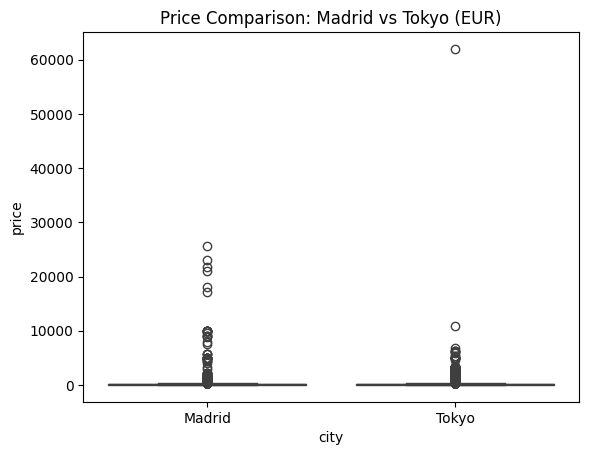

In [14]:
sns.boxplot(x="city", y="price", data=df)
plt.title("Price Comparison: Madrid vs Tokyo (EUR)")
plt.show()

## Preliminary Insights

We conducted an initial exploratory data analysis (EDA) on Airbnb listings in Madrid and Tokyo, focusing on price behavior.

### Key Findings

- **Similar average pricing**  
  After currency normalization, both cities show very similar average prices, around **150 EUR per listing**.

- **Slightly higher median in Madrid**  
  The median price in Madrid is slightly higher than in Tokyo, suggesting that typical listings in Madrid may be marginally more expensive.

- **High variability in both markets**  
  Both cities exhibit a large spread in prices, indicating strong segmentation between:
  - budget accommodations  
  - mid-range listings  
  - luxury properties  

- **Presence of extreme outliers**  
  Very high maximum prices in both cities suggest the existence of luxury listings that significantly skew the distribution.

### Interpretation

These results indicate that, despite being very different markets geographically and structurally, Madrid and Tokyo show **comparable pricing levels** once currency differences are accounted for. However, both markets are highly heterogeneous, which highlights the importance of further analysis on pricing drivers.

### Next Steps

- Identify key features influencing price (e.g., room type, location, availability)
- Perform feature engineering
- Build a price prediction model
- Develop a chatbot to answer user queries based on the data